# Sprint 28 — Plots de présentation
## Benchmark INT8 vs FP32 (PC) — Grille 4 modèles × 5 datasets (Gap 3)

**Expériences couvertes** : `exp_S28_PC_ewc_hdc/` (10 JSON) + `exp_S28_PC_tinyol_maha/` (10 JSON)

**Modèles** : EWC, HDC, TinyOL, Mahalanobis · **Datasets** : CMAPSS, CWRU, Monitoring, Paderborn, Pronostia

**Contenu** :
- Heatmap `delta_metric` (INT8 − FP32) sur la grille 4×5
- Réduction RAM `ram_ratio` FP32/INT8
- Métrique FP32 vs INT8 par modèle
- Checklist préservation métrique + cas Mahalanobis dégradés (fallback Q15)
- Tableau récapitulatif coloré par conformité Gap 3

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path("..")
EXP = ROOT / "experiments"
FIG_DIR = EXP / "figures" / "sprint28"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

MODELS = ["ewc", "hdc", "tinyol", "mahalanobis"]
DATASETS = ["cmapss", "cwru", "monitoring", "paderborn", "pronostia"]
DIRS = {
    "ewc": EXP / "exp_S28_PC_ewc_hdc",
    "hdc": EXP / "exp_S28_PC_ewc_hdc",
    "tinyol": EXP / "exp_S28_PC_tinyol_maha",
    "mahalanobis": EXP / "exp_S28_PC_tinyol_maha",
}

records = []
for model in MODELS:
    for ds in DATASETS:
        path = DIRS[model] / f"results_{model}_{ds}.json"
        rec = {"model": model, "dataset": ds}
        if path.exists():
            d = json.load(open(path))
            if d.get("status") in ("n_a", "blocked") or "fp32" not in d:
                rec.update({"metric_name": None, "fp32_metric": np.nan, "int8_metric": np.nan,
                            "delta": np.nan, "ram_ratio": np.nan, "gap3_metric_ok": None,
                            "gap3_ram_ok": None, "status": d.get("status", "n_a")})
            else:
                rec.update({
                    "metric_name": d["fp32"]["metric_name"],
                    "fp32_metric": d["fp32"]["metric_value"],
                    "int8_metric": d["int8"]["metric_value"],
                    "fp32_ram": d["fp32"]["ram_bytes"], "int8_ram": d["int8"]["ram_bytes"],
                    "delta": d["delta_metric"], "ram_ratio": d["ram_ratio"],
                    "gap3_metric_ok": d["gap3_metric_ok"], "gap3_ram_ok": d["gap3_ram_ok"],
                    "status": "ok"})
        else:
            rec.update({"metric_name": None, "fp32_metric": np.nan, "int8_metric": np.nan,
                        "delta": np.nan, "ram_ratio": np.nan, "gap3_metric_ok": None,
                        "gap3_ram_ok": None, "status": "missing"})
        records.append(rec)

df = pd.DataFrame(records)
n_ok = df["status"].eq("ok").sum()
n_metric_ok = df["gap3_metric_ok"].eq(True).sum()
n_ram_ok = df["gap3_ram_ok"].eq(True).sum()
print(f"Donnees chargees : {n_ok}/{len(df)} cellules valides")
print(f"  Gap 3 metrique preservee : {n_metric_ok}/{n_ok}")
print(f"  Gap 3 RAM reduite        : {n_ram_ok}/{n_ok}")
df[["model", "dataset", "metric_name", "fp32_metric", "int8_metric", "delta", "ram_ratio", "status"]]

Donnees chargees : 19/20 cellules valides
  Gap 3 metrique preservee : 12/19
  Gap 3 RAM reduite        : 19/19


,model,dataset,metric_name,fp32_metric,int8_metric,delta,ram_ratio,status
0,ewc,cmapss,auroc,0.767843,0.773394,0.005551,4.000000,ok
1,ewc,cwru,auroc,0.999840,0.999680,-0.000160,4.000000,ok
2,ewc,monitoring,auroc,0.939425,0.938679,-0.000746,4.000000,ok
3,ewc,paderborn,auroc,NaN,NaN,NaN,4.000000,ok
4,ewc,pronostia,auroc,0.988443,0.988336,-0.000107,4.000000,ok
5,hdc,cmapss,f1_macro,0.722500,0.722500,0.000000,2.331599,ok
6,hdc,cwru,f1_macro,0.928976,0.928976,0.000000,2.329870,ok
7,hdc,monitoring,f1_macro,0.757609,0.757609,0.000000,2.331599,ok
8,hdc,paderborn,NaN,NaN,NaN,NaN,NaN,n_a
9,hdc,pronostia,f1_macro,0.708736,0.708736,0.000000,2.331599,ok


## 1. Heatmap `delta_metric` (INT8 − FP32) — grille 4×5

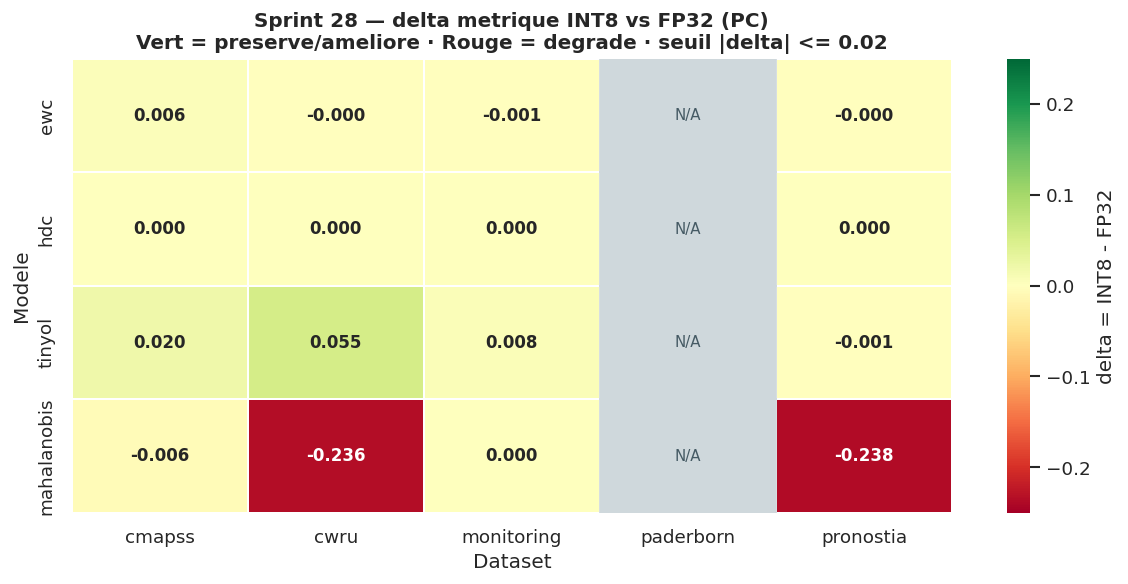

In [2]:
pivot = df.pivot(index="model", columns="dataset", values="delta").reindex(index=MODELS, columns=DATASETS)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", center=0, vmin=-0.25, vmax=0.25,
            linewidths=1, linecolor="white", cbar_kws={"label": "delta = INT8 - FP32"},
            ax=ax, annot_kws={"fontsize": 10, "fontweight": "bold"})
# Marquer les cellules N/A
for i, model in enumerate(MODELS):
    for j, ds in enumerate(DATASETS):
        if pd.isna(pivot.loc[model, ds]):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color="#CFD8DC"))
            ax.text(j+0.5, i+0.5, "N/A", ha="center", va="center", fontsize=9, color="#455A64")
ax.set_title("Sprint 28 — delta metrique INT8 vs FP32 (PC)\n"
             "Vert = preserve/ameliore · Rouge = degrade · seuil |delta| <= 0.02",
             fontweight="bold")
ax.set_xlabel("Dataset"); ax.set_ylabel("Modele")
plt.tight_layout()
plt.savefig(FIG_DIR / "delta_metric_heatmap.png", bbox_inches="tight")
plt.show()

## 2. Réduction RAM — `ram_ratio` FP32 / INT8

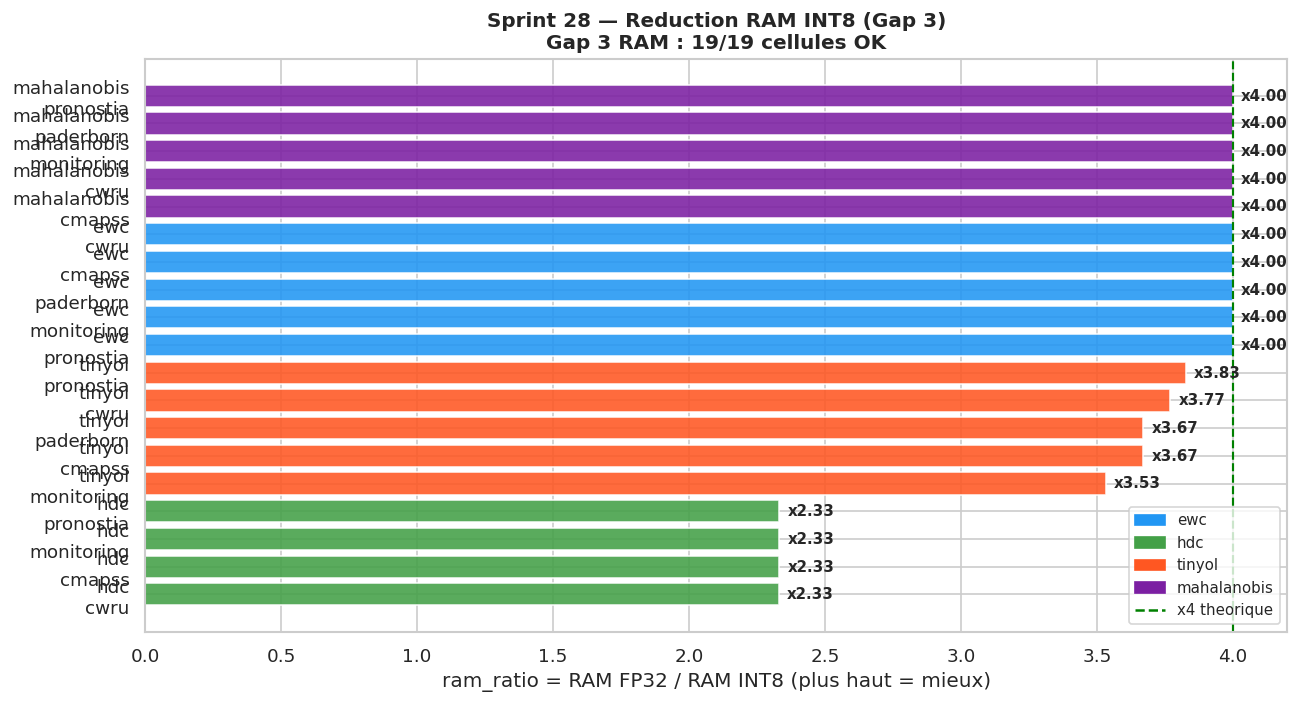

In [3]:
ram = df.dropna(subset=["ram_ratio"]).copy()
ram["label"] = ram["model"] + "\n" + ram["dataset"]
ram = ram.sort_values("ram_ratio", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
palette = {"ewc": "#2196F3", "hdc": "#43A047", "tinyol": "#FF5722", "mahalanobis": "#7B1FA2"}
colors = [palette[m] for m in ram["model"]]
bars = ax.barh(ram["label"], ram["ram_ratio"], color=colors, alpha=0.88, edgecolor="white")
for bar, v in zip(bars, ram["ram_ratio"]):
    ax.text(v+0.03, bar.get_y()+bar.get_height()/2, f"x{v:.2f}", va="center", fontsize=9, fontweight="bold")
ax.axvline(4.0, color="green", linestyle="--", linewidth=1.3, label="Reduction theorique x4 (INT8)")
ax.set_xlabel("ram_ratio = RAM FP32 / RAM INT8 (plus haut = mieux)")
ax.set_title("Sprint 28 — Reduction RAM INT8 (Gap 3)\n"
             f"Gap 3 RAM : {df['gap3_ram_ok'].eq(True).sum()}/{df['status'].eq('ok').sum()} cellules OK",
             fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=m) for m, c in palette.items()] +
          [plt.Line2D([0],[0], color="green", linestyle="--", label="x4 theorique")], fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "ram_ratio_bars.png", bbox_inches="tight")
plt.show()

## 3. Métrique FP32 vs INT8 — par modèle / dataset

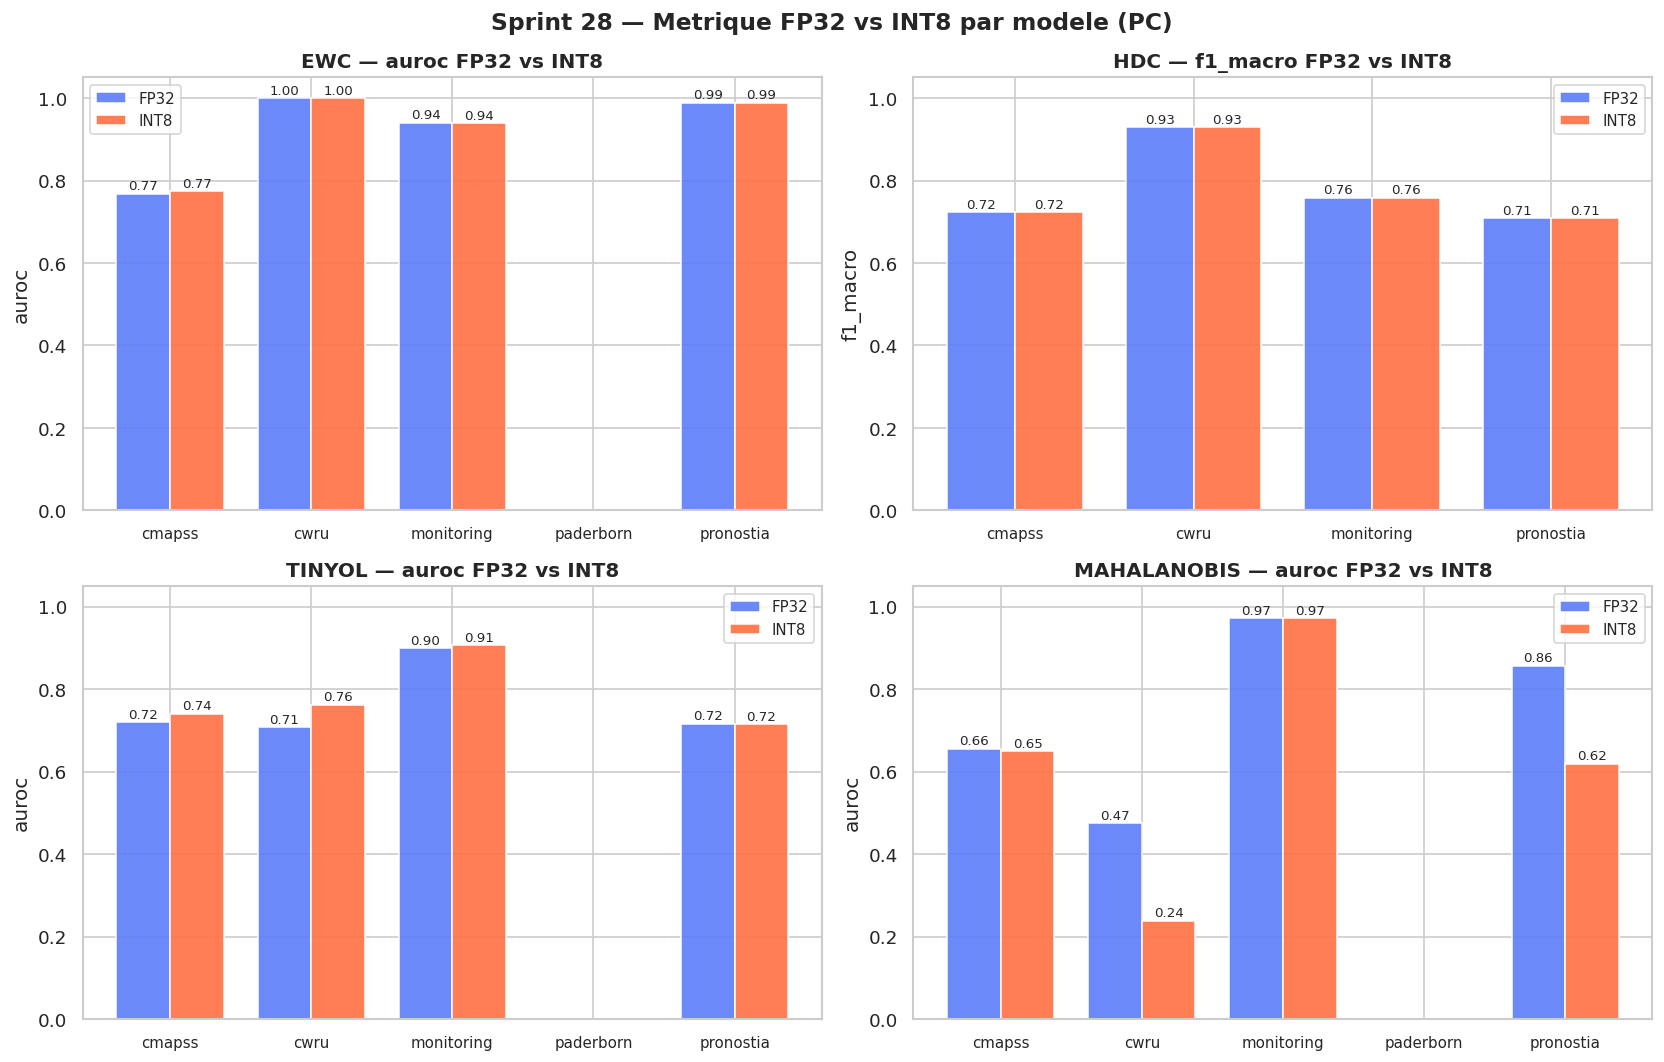

In [4]:
ok = df[df["status"].eq("ok")].copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, model in zip(axes.ravel(), MODELS):
    sub = ok[ok["model"].eq(model)]
    x = np.arange(len(sub)); w = 0.38
    ax.bar(x - w/2, sub["fp32_metric"], w, label="FP32", color="#5C7CFA", alpha=0.9, edgecolor="white")
    ax.bar(x + w/2, sub["int8_metric"], w, label="INT8", color="#FF7043", alpha=0.9, edgecolor="white")
    for xi, (f, q) in enumerate(zip(sub["fp32_metric"], sub["int8_metric"])):
        ax.text(xi - w/2, f+0.01, f"{f:.2f}", ha="center", fontsize=8)
        ax.text(xi + w/2, q+0.01, f"{q:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(sub["dataset"], fontsize=9)
    mname = sub["metric_name"].iloc[0] if len(sub) else ""
    ax.set_ylim(0, 1.05); ax.set_ylabel(mname)
    ax.set_title(f"{model.upper()} — {mname} FP32 vs INT8", fontweight="bold")
    ax.legend(fontsize=9)
fig.suptitle("Sprint 28 — Metrique FP32 vs INT8 par modele (PC)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "metric_fp32_vs_int8.png", bbox_inches="tight")
plt.show()

## 4. Checklist préservation métrique + cas Mahalanobis dégradés

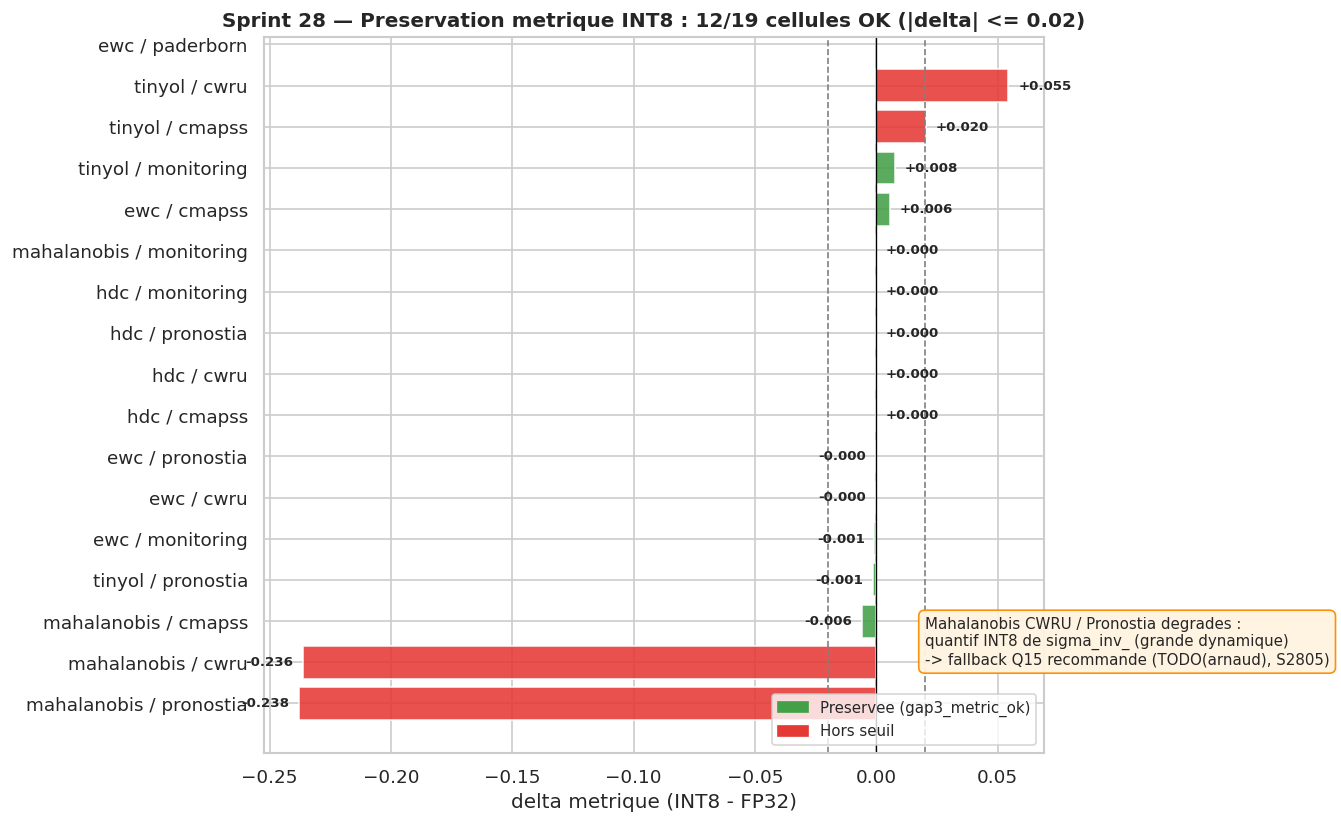

In [5]:
ok = df[df["status"].eq("ok")].copy().sort_values("delta")
ok["label"] = ok["model"] + " / " + ok["dataset"]
colors = ["#43A047" if m else "#E53935" for m in ok["gap3_metric_ok"]]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(ok["label"], ok["delta"], color=colors, alpha=0.88, edgecolor="white")
for bar, v in zip(bars, ok["delta"]):
    off = 0.004 if v >= 0 else -0.004
    ax.text(v+off, bar.get_y()+bar.get_height()/2, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8, fontweight="bold")
ax.axvline(0.02, color="gray", linestyle="--", linewidth=1, label="+/- 0.02 (seuil preservation)")
ax.axvline(-0.02, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="black", linewidth=0.8)

n_ok = df["gap3_metric_ok"].eq(True).sum(); n_tot = df["status"].eq("ok").sum()
ax.text(0.02, 1.5,
        "Mahalanobis CWRU / Pronostia degrades :\n"
        "quantif INT8 de sigma_inv_ (grande dynamique)\n"
        "-> fallback Q15 recommande (TODO(arnaud), S2805)",
        fontsize=9, va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF3E0", edgecolor="#FB8C00", alpha=0.95))
ax.set_xlabel("delta metrique (INT8 - FP32)")
ax.set_title(f"Sprint 28 — Preservation metrique INT8 : {n_ok}/{n_tot} cellules OK (|delta| <= 0.02)",
             fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#43A047", label="Preservee (gap3_metric_ok)"),
                   Patch(color="#E53935", label="Hors seuil")], fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "metric_preservation_checklist.png", bbox_inches="tight")
plt.show()

## 5. Tableau récapitulatif 4×5 — conformité Gap 3

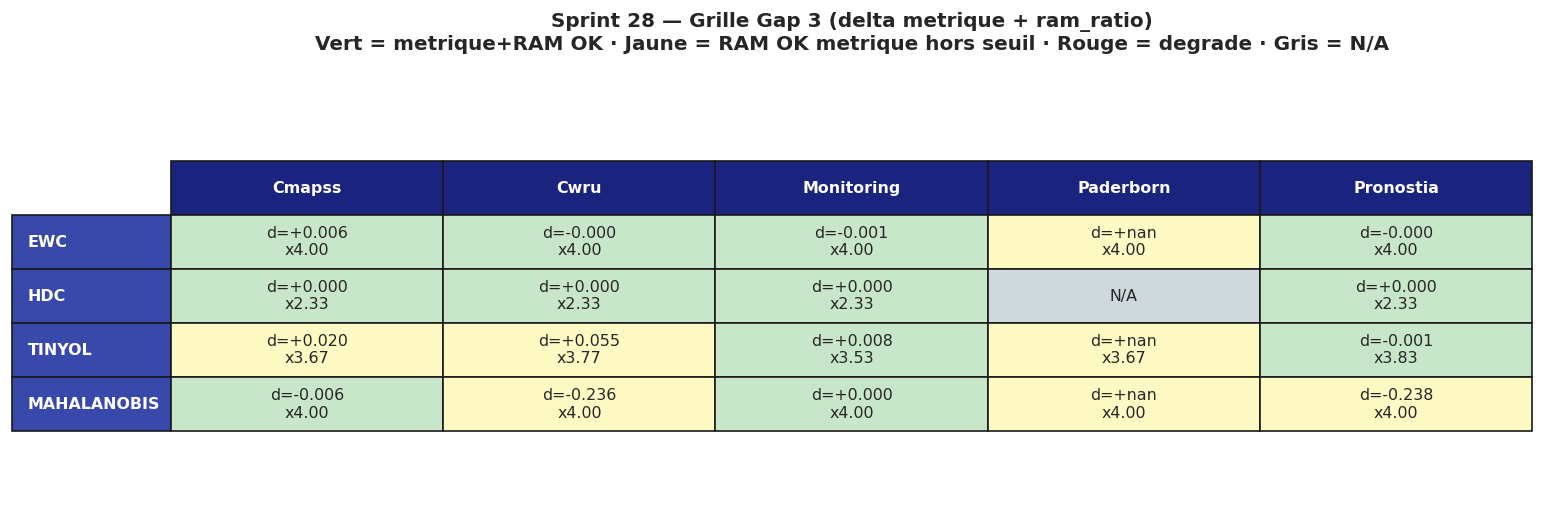

In [6]:
def cell_text(r):
    if r["status"] != "ok":
        return "N/A"
    return f"d={r['delta']:+.3f}\nx{r['ram_ratio']:.2f}"

grid = df.set_index(["model", "dataset"])
cell_txt, cell_col = [], []
for model in MODELS:
    row_txt, row_col = [], []
    for ds in DATASETS:
        r = grid.loc[(model, ds)]
        row_txt.append(cell_text(r))
        if r["status"] != "ok":
            row_col.append("#CFD8DC")
        elif r["gap3_metric_ok"] and r["gap3_ram_ok"]:
            row_col.append("#C8E6C9")
        elif r["gap3_ram_ok"]:
            row_col.append("#FFF9C4")
        else:
            row_col.append("#FFCDD2")
    cell_txt.append(row_txt); cell_col.append(row_col)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis("off")
table = ax.table(cellText=cell_txt, rowLabels=[m.upper() for m in MODELS],
                 colLabels=[d.capitalize() for d in DATASETS], cellLoc="center",
                 loc="center", cellColours=cell_col)
table.auto_set_font_size(False); table.set_fontsize(9.5); table.scale(1, 2.6)
for j in range(len(DATASETS)):
    table[(0, j)].set_facecolor("#1A237E"); table[(0, j)].set_text_props(color="white", fontweight="bold")
for i in range(len(MODELS)):
    table[(i+1, -1)].set_facecolor("#3949AB"); table[(i+1, -1)].set_text_props(color="white", fontweight="bold")
ax.set_title("Sprint 28 — Grille Gap 3 (delta metrique + ram_ratio)\n"
             "Vert = metrique+RAM OK · Jaune = RAM OK metrique hors seuil · Rouge = degrade · Gris = N/A",
             fontweight="bold", fontsize=12, pad=18)
plt.tight_layout()
plt.savefig(FIG_DIR / "gap3_summary_grid.png", bbox_inches="tight", dpi=150)
plt.show()

## Récapitulatif figures générées

In [7]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures sauvegardees dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


5 figures sauvegardees dans ../experiments/figures/sprint28:
  delta_metric_heatmap.png
  gap3_summary_grid.png
  metric_fp32_vs_int8.png
  metric_preservation_checklist.png
  ram_ratio_bars.png
